e-commerce co-purchase network, where:

Nodes are products,

Edges indicate that two products are frequently bought together,

Features come from product descriptions as simplified word-based attributes,

Labels represent product categories (e.g., Laptop, Accessory, Printer).

This mirrors datasets such as the Amazon Computers co-purchase graph used for node classification within graph learning research

In [1]:
import pandas as pd

# Nodes and features
products = ['P1','P2','P3','P4','P5']
features = [
    [1,1,0],  # P1: keyboard, portable
    [0,1,1],  # P2: portable, print
    [0,0,1],  # P3: print
    [1,0,0],  # P4: keyboard
    [0,1,0],  # P5: portable
]

In [2]:
features_df = pd.DataFrame(features, columns=['feature_keyboard','feature_portable','feature_print'])
features_df.insert(0, 'node_id', products)

In [3]:
edges = [
    ('P1','P2'),
    ('P2','P3'),
    ('P3','P4'),
    ('P4','P5'),
    ('P1','P5'),
]
edges_df = pd.DataFrame(edges, columns=['source','target'])

In [4]:
# Labels
labels = [
    ('P1','Laptop'),
    ('P2','Printer'),
    ('P3','Accessory'),
    ('P4','Laptop'),
    ('P5','Accessory'),
]
labels_df = pd.DataFrame(labels, columns=['node_id','label'])

In [ ]:
# Save to files
features_df.to_csv('data/raw/features.csv', index=False)
edges_df.to_csv('data/raw/edges.csv', index=False)
labels_df.to_csv('data/raw/labels.csv', index=False)

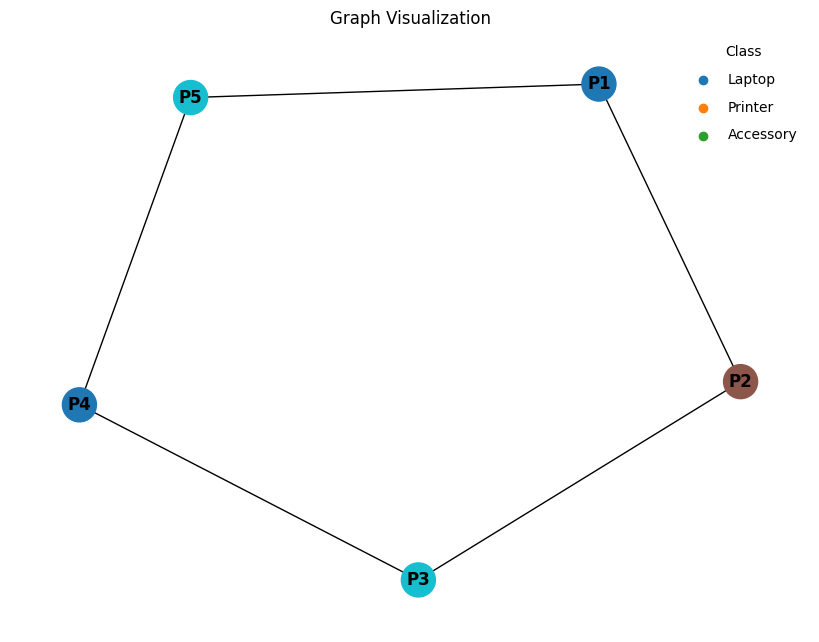

In [60]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load CSVs
features_df = pd.read_csv("data/raw/features.csv")  # contains node_id + feature columns
edges_df = pd.read_csv("data/raw/edges.csv")        # contains source,target
labels_df = pd.read_csv("data/raw/labels.csv")      # contains node_id,label

# Build graph
G = nx.Graph()
for nid in features_df['node_id']:
    G.add_node(nid)

for _, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'])

# Map labels to colors
class_names = labels_df['label'].unique()
class_colors = {cls: i for i, cls in enumerate(class_names)}
node_colors = [class_colors[labels_df.loc[labels_df.node_id==nid, "label"].values[0]] for nid in G.nodes]

# Draw graph
plt.figure(figsize=(8,6))
nx.draw(
    G,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=600,
    font_weight='bold'
)
# Add legend
for cls, idx in class_colors.items():
    plt.scatter([], [], c=[plt.cm.tab10(idx)], label=cls)
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title="Class")
plt.title("Graph Visualization")
plt.show()


1. What the nodes represent

Each node in the plot corresponds to an entity (or sample) from your features.csv file.

They are labeled 0, 1, 2, ... because we indexed them when adding them to the graph.

2. What the edges represent

An edge is drawn between two nodes if there’s a row in edges.csv connecting them.

This shows relationships, similarities, or links between entities (depending on what your edge data means).

In [62]:
pip install pyvis

   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---------------------------------------- 756.0/756.0 kB 4.0 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [jsonpickle]
   -------------------- ------------------- 1/2 [pyvis]
   -------------------- ------------------- 1/2 [pyvis]
   ---------------------------------------- 2/2 [pyvis]

Note: you may need to restart the kernel to use updated packages.


In [65]:
from pyvis.network import Network
import pandas as pd

# Load CSVs
features_df = pd.read_csv("data/raw/features.csv")
edges_df = pd.read_csv("data/raw/edges.csv")
labels_df = pd.read_csv("data/raw/labels.csv")

# Initialize PyVis network
net = Network(height="600px", width="100%", notebook=True)

# Assign colors for each class
class_colors_list = ["red", "green", "blue", "orange", "purple", "cyan", "magenta"]
class_names = labels_df['label'].unique()
class_colors = {cls: color for cls, color in zip(class_names, class_colors_list)}

# Add nodes
for _, row in features_df.iterrows():
    nid = row['node_id']
    label = labels_df.loc[labels_df.node_id==nid, "label"].values[0]
    net.add_node(
        nid,
        label=nid,
        title=f"Node ID: {nid}<br>Label: {label}",
        color=class_colors[label]
    )

# Add edges
for _, row in edges_df.iterrows():
    net.add_edge(row['source'], row['target'])

# Show interactive HTML
net.show("graph_visualization.html")


graph_visualization.html


In [6]:
from __future__ import annotations
import argparse
import os
import random
from pathlib import Path
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report

from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GCNConv

In [33]:
from torch_geometric.data import Data, Dataset

In [30]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

random.seed(seed)

This sets the seed for Python’s built-in random module.

Any random operations using random (like random.random(), random.randint()) will produce the same sequence of values if the same seed is given.

2. np.random.seed(seed)

This sets the seed for NumPy’s random number generator.

Functions like np.random.rand(), np.random.randn() will return deterministic outputs when seeded.

3. torch.manual_seed(seed)

This sets the seed for PyTorch operations on the CPU.

Any random initialization (weights, dropout patterns, data shuffling in DataLoader without workers) becomes deterministic.

In [31]:
def safe_load_checkpoint(ckpt_path, model=None, device=None, load_state_dict=True):
    """
    Safely loads a checkpoint in PyTorch 2.6+ (handles DataEdgeAttr)
    """
    ckpt_path = Path(ckpt_path)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    with torch.serialization.safe_globals([torch_geometric.data.data.DataEdgeAttr]):
        checkpoint = torch.load(ckpt_path, weights_only=False, map_location=device)

    if model is not None and load_state_dict:
        if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            model.load_state_dict(checkpoint["state_dict"])
        else:
            model.load_state_dict(checkpoint)

    return checkpoint

PyTorch 2.6 introduced a stricter checkpoint loading mechanism:

By default, torch.load() uses weights_only=True to avoid arbitrary code execution risks.

If your checkpoint contains custom Python objects (like torch_geometric.data.data.DataEdgeAttr), PyTorch won’t load them unless you explicitly allow them.

This function solves that problem by explicitly allowlisting PyG-specific objects using torch.serialization.safe_globals.

ckpt_path: Path to the saved checkpoint file (.pt or .pth).

model: Optional PyTorch model to directly load weights into.

device: Where to map tensors after loading (e.g., "cpu" or "cuda").

load_state_dict: If True, automatically loads weights into the given model.

In [ ]:
from torch_geometric.data import Dataset, Data
from pathlib import Path
import pandas as pd
import torch
import numpy as np

class CSVDataset(Dataset):
    def __init__(self, root, seed=42):
        super().__init__(root)
        self.root = Path(root)
        self.seed = seed

        # Load CSVs
        features = pd.read_csv(self.root / "raw" / "features.csv").set_index("node_id")
        labels = pd.read_csv(self.root / "raw" / "labels.csv").set_index("node_id")
        edges = pd.read_csv(self.root / "raw" / "edges.csv")

        # Map node IDs to indices
        node_ids = list(features.index)
        self.node_map = {nid: i for i, nid in enumerate(node_ids)}
        x = torch.tensor(features.values, dtype=torch.float)

        # Convert string labels to integer class indices if needed
        if labels.dtypes[0] == object or labels.values.dtype.kind in {'U', 'S'}:
            class_names = sorted(labels.iloc[:, 0].unique())
            class_map = {name: i for i, name in enumerate(class_names)}
            y = torch.tensor(labels.iloc[:, 0].map(class_map).values, dtype=torch.long)
        else:
            y = torch.tensor(labels.values, dtype=torch.long)
            class_names = sorted(np.unique(labels.values))

        # If labels are strings (like "Laptop", "Printer"):

        # Create a mapping ({"Accessory": 0, "Laptop": 1, "Printer": 2}).

        # Convert labels into integers for classification.

        # If labels are already integers, just load them directly.

        # Save class_names so predictions can be mapped back to human-readable form.

        # Edge index
        edge_index = torch.tensor(
            [[self.node_map[s], self.node_map[t]] for s, t in zip(edges.source, edges.target)],
            dtype=torch.long
        ).t().contiguous()

        # Converts edge list into a 2×E tensor of source/target indices, as required by PyTorch Geometric.

        # .t() transposes it into shape [2, num_edges].

        # .contiguous() ensures the tensor memory layout is consistent.

        # Build Data object
        self.data = Data(x=x, edge_index=edge_index, y=y)
        self.data.node_ids = node_ids
        self.data.class_names = class_names

        # Wraps everything into a Data object:

        # x → node features

        # edge_index → graph connectivity

        # y → node labels

        # Adds metadata for later use (node IDs and class names).

    def len(self):
        return 1

    def get(self, idx):
        return self.data


This CSVDataset class converts your CSV files (features.csv, labels.csv, edges.csv) into a PyTorch Geometric Data object, which is the standard format for graph neural networks (GNNs). Let’s break it down step by step.

What the class does

Reads node features, node labels, and graph edges from CSV files.

Converts string labels (e.g., "Laptop", "Printer") into integer indices for classification.

Builds a graph structure (x, edge_index, y) that GNNs like GCN can process.

Stores additional metadata (node IDs and class names) for later use in predictions.

data.x: node features [num_nodes, num_features]

data.y: integer labels [num_nodes]

data.edge_index: graph edges [2, num_edges]

data.node_ids: original node IDs (list)

data.class_names: human-readable class labels

In [35]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


What this model does

Takes in node features (x) and graph structure (edge_index).

Passes them through two graph convolution layers (GCNConv).

Uses ReLU activation and dropout between layers to add non-linearity and prevent overfitting.

Outputs logits per node — which can be turned into probabilities with F.softmax during inference.

in_channels → number of features per node (from dataset).

hidden → number of hidden units in the first GCN layer.

out_channels → number of classes to predict (from dataset labels).

dropout → probability of randomly dropping neurons during training for regularization.

Creates:

conv1: first graph convolution (input → hidden)

conv2: second graph convolution (hidden → output classes)

x = node feature matrix [num_nodes, in_channels].

edge_index = graph connectivity [2, num_edges].

The output of conv2 is:

Shape: [num_nodes, out_channels]

For each node, gives unnormalized scores (logits) for each clas

x = node feature matrix [num_nodes, in_channels].

edge_index = graph connectivity [2, num_edges].

The output of conv2 is:

Shape: [num_nodes, out_channels]

For each node, gives unnormalized scores (logits) for each class.

In [36]:
def train(model, data, lr=0.01, weight_decay=5e-4, epochs=100, device="cpu", ckpt_path=None):
    device = torch.device(device)
    model.to(device)
    data = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out, data.y.view(-1))
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss and ckpt_path:
            best_loss = loss.item()
            torch.save({"state_dict": model.state_dict()}, ckpt_path)

        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Loss {loss.item():.4f}")

device: converts "cpu" or "cuda" string into a proper PyTorch device.

model.to(device): moves the model’s parameters to the device (CPU or GPU).

data.to(device): moves the input graph (node features, edges, labels) to the same device.

optimizer: Adam optimizer with:

lr → learning rate (how big parameter updates are)

weight_decay → L2 regularization (helps prevent overfitting)

best_loss: initialized to infinity so any real loss will be smaller at first — used to track the best model.

model.train(): sets training mode (enables dropout and batch norm updates).

optimizer.zero_grad(): prevents gradient accumulation from previous steps.

out = model(...): forward pass → produces [num_nodes, num_classes] logits.

loss = F.cross_entropy(...): standard classification loss between predictions and labels.

loss.backward(): computes gradients w.r.t. model parameters.

optimizer.step(): updates model parameters using gradients.

In [37]:
def predict_nodes(model, data, node_ids):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out.argmax(dim=1)
    df = pd.DataFrame({
        "node_id": node_ids,
        "predicted_class": [data.class_names[i] for i in preds.tolist()]
    })
    return df

model → A trained graph neural network (PyTorch or PyTorch Geometric).

data → A graph object (likely from PyTorch Geometric), which contains:

data.x → node features.

data.edge_index → graph connectivity.

data.class_names → list of class labels as strings.

node_ids → A list of identifiers to label each node in the output DataFrame.

This sets the model to evaluation mode (disables dropout, batch norm updates).

Ensures no gradients are computed, saving memory and time during inference.

The model produces an output tensor of shape (num_nodes, num_classes).

Each row corresponds to a node, and each column is the predicted score for a class.

For each node, picks the index of the highest score.

Result → a tensor of shape (num_nodes,) with integers representing class indices.

node_id column → comes from the input node_ids.

predicted_class column → converts the integer predictions into human-readable labels using data.class_names.

Final output is a table with two columns:

Node ID

Predicted Class Name

node_ids = [101, 102, 103]

preds = tensor([0, 2, 1])

data.class_names = ["Cat", "Dog", "Bird"]

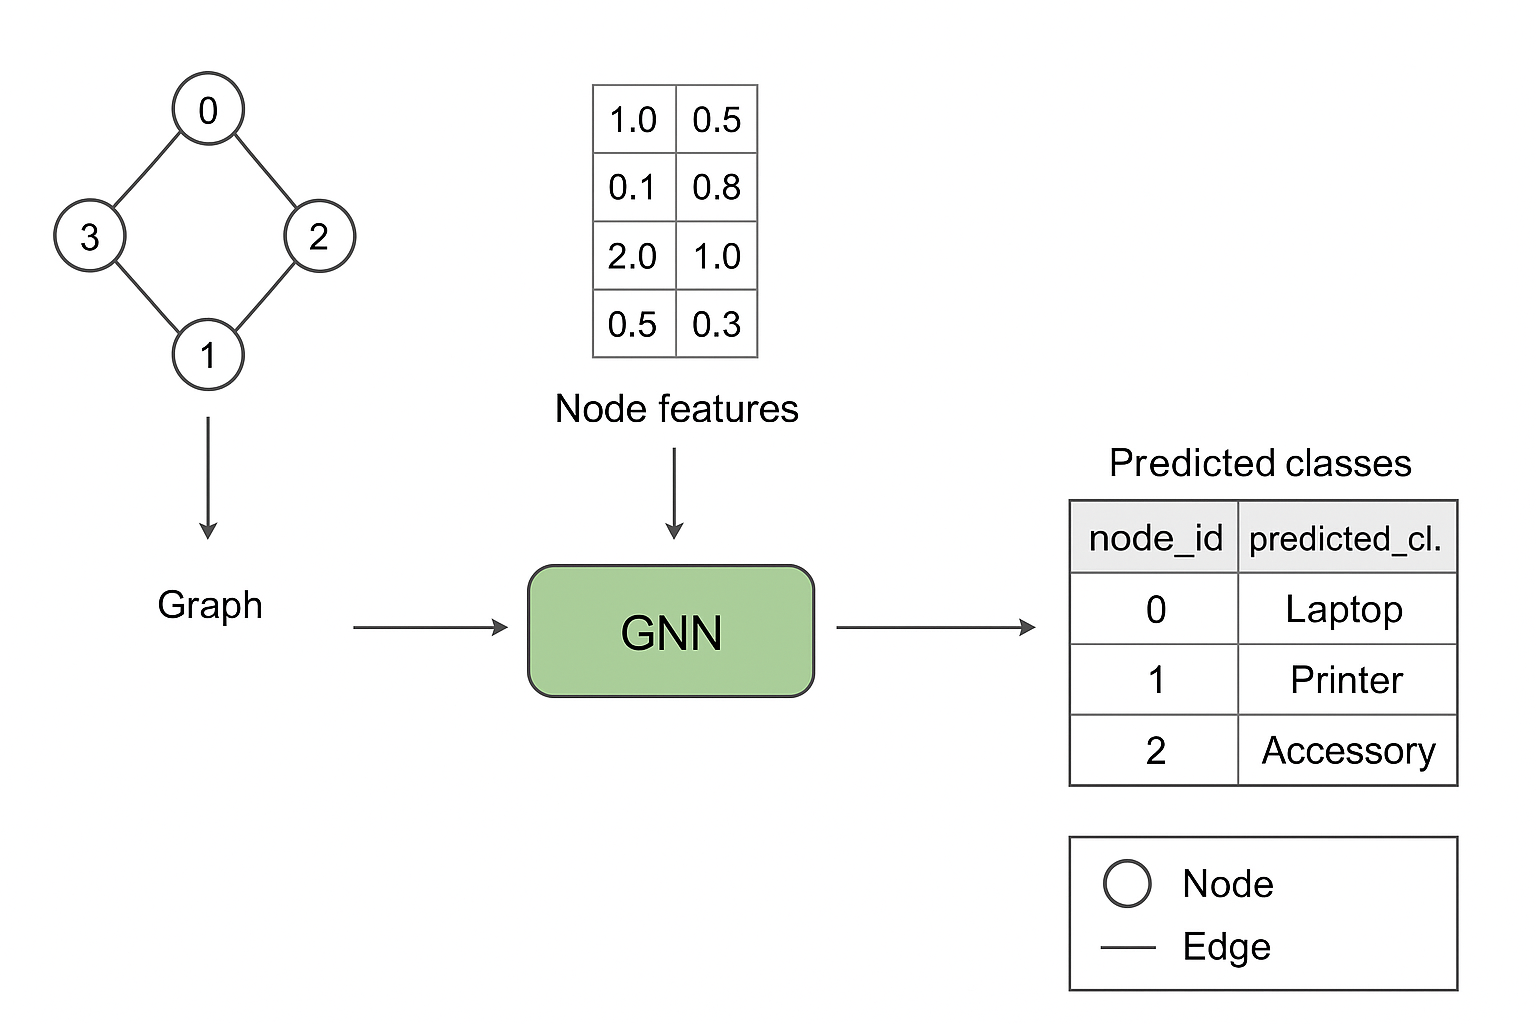

In [38]:
def load_graph_from_dir(data_dir):
    root = Path(data_dir)
    return CSVDataset(root)[0]

In [41]:
import numpy as np

In [45]:
import argparse
import torch  # Assuming this is imported elsewhere, as referenced in --device

parser = argparse.ArgumentParser()
parser.add_argument("--data_dir", type=str, required=True)
parser.add_argument("--hidden", type=int, default=64)
parser.add_argument("--dropout", type=float, default=0.5)
parser.add_argument("--epochs", type=int, default=200)
parser.add_argument("--lr", type=float, default=0.01)
parser.add_argument("--weight_decay", type=float, default=5e-4)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
parser.add_argument("--ckpt", type=str, default="./artifacts/best.pt")
parser.add_argument("--predict", nargs="*", help="List of node IDs to predict after training")
parser.add_argument("--predict_all", action="store_true", help="Predict all nodes (inference-only mode)")

# Simulate command-line args (replace '/path/to/your/data' with your actual directory)
simulated_args = ['--data_dir', 'data']  # Add more flags as needed, e.g., ['--data_dir', '/path', '--epochs', '100']
args = parser.parse_args(simulated_args)

# Now you can access args.data_dir, args.hidden, etc.
print(args)

set_seed(args.seed)

# Ensure raw folder exists
root = Path(args.data_dir)
(root / "raw").mkdir(parents=True, exist_ok=True)
for fname in ["edges.csv", "features.csv", "labels.csv"]:
    src = root / fname
    dst = root / "raw" / fname
    if src.exists() and not dst.exists():
        src.replace(dst)

Namespace(data_dir='data', hidden=64, dropout=0.5, epochs=200, lr=0.01, weight_decay=0.0005, seed=42, device='cpu', ckpt='./artifacts/best.pt', predict=None, predict_all=False)


In [46]:
root

WindowsPath('data')

In [51]:
# Load dataset and model
dataset = CSVDataset(root=str(root), seed=args.seed)
data = dataset[0]

in_channels = data.num_node_features
out_channels = len(data.class_names)

model = GCN(in_channels, args.hidden, out_channels, dropout=args.dropout)

# Train
train(model, data, lr=args.lr, weight_decay=args.weight_decay, epochs=args.epochs,
        device=args.device, ckpt_path=args.ckpt)

# Predict selected nodes
if args.predict:
    df = predict_nodes(model, data, args.predict)
    print("\nPredictions:")
    print(df.to_string(index=False))

# Predict all nodes
if args.predict_all:
    if args.ckpt and Path(args.ckpt).exists():
        safe_load_checkpoint(args.ckpt, model=model, device=args.device)
    data_inf = load_graph_from_dir(args.data_dir)
    df = predict_nodes(model, data_inf, data_inf.node_ids)
    out_path = Path(args.data_dir) / "predictions.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved predictions to {out_path}")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12392\1362000689.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if labels.dtypes[0] == object or labels.values.dtype.kind in {'U', 'S'}:


Epoch 0: Loss 1.0961
Epoch 20: Loss 0.9783
Epoch 40: Loss 0.8240
Epoch 60: Loss 0.7666
Epoch 80: Loss 0.7293
Epoch 100: Loss 0.7251
Epoch 120: Loss 0.6347
Epoch 140: Loss 0.5998
Epoch 160: Loss 0.6900
Epoch 180: Loss 0.9165


In [52]:
import torch

def predict_nodes(model, data, node_ids=None, device="cpu"):
    """
    Predict classes for given node_ids or all nodes if node_ids=None.
    """
    model.eval()
    device = torch.device(device)
    model.to(device)
    data = data.to(device)

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out.argmax(dim=1).cpu().numpy()

    # Use all nodes if node_ids not provided
    if node_ids is None:
        node_ids = data.node_ids

    # Map predictions to class names
    class_map = data.class_names
    pred_classes = [class_map[preds[data.node_ids.index(nid)]] for nid in node_ids]

    import pandas as pd
    df = pd.DataFrame({"node_id": node_ids, "predicted_class": pred_classes})
    return df


In [55]:
import torch_geometric

In [53]:
def safe_load_checkpoint(ckpt_path, model, device="cpu"):
    """Safe loader for PyTorch 2.6+"""
    device = torch.device(device)
    with torch.serialization.safe_globals([torch_geometric.data.data.DataEdgeAttr]):
        checkpoint = torch.load(ckpt_path, weights_only=False, map_location=device)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        model.load_state_dict(checkpoint)
    return model

In [56]:
# Paths
data_dir = "data"            # CSV folder with raw/features.csv, labels.csv, edges.csv
ckpt_path = "artifacts/best.pt"  # Trained model checkpoint

# Load dataset
dataset = CSVDataset(data_dir)
data = dataset[0]

# Build model
in_channels = data.num_node_features
out_channels = len(data.class_names)
hidden = 64
model = GCN(in_channels, hidden, out_channels, dropout=0.5)

# Load trained weights safely
model = safe_load_checkpoint(ckpt_path, model, device="cpu")

# Predict all nodes
df_all = predict_nodes(model, data, device="cpu")
print(df_all)

# Predict selected nodes only
selected_nodes = [data.node_ids[0], data.node_ids[1]]  # Example node IDs
df_selected = predict_nodes(model, data, node_ids=selected_nodes, device="cpu")
print(df_selected)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_12392\1362000689.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if labels.dtypes[0] == object or labels.values.dtype.kind in {'U', 'S'}:


  node_id predicted_class
0      P1          Laptop
1      P2         Printer
2      P3       Accessory
3      P4          Laptop
4      P5          Laptop
  node_id predicted_class
0      P1          Laptop
1      P2         Printer


node_id → This is the identifier of each node in your graph. In your CSV dataset, these were the original node IDs from features.csv or labels.csv (e.g., P1, P2, …).

predicted_class → This is the class predicted by your trained GCN model for each node. The model looks at the node features and the graph structure (edges) to determine this.

For example:

P1 → predicted as Laptop

P2 → predicted as Printer

P3 → predicted as Accessory

2️ How the model makes these predictions

Feature propagation: The GCN aggregates information from neighboring nodes via edge_index. Each node’s features are combined with its neighbors’ features.

Hidden layers: The aggregated features are passed through hidden layers with ReLU activation and optional dropout.

Output layer: The final layer outputs logits for each class.

Argmax: The class with the highest logit value is selected as the predicted class.

Mapping back to labels: If your original labels were strings (Laptop, Printer), the integer prediction is mapped back to the original class name using data.class_names.

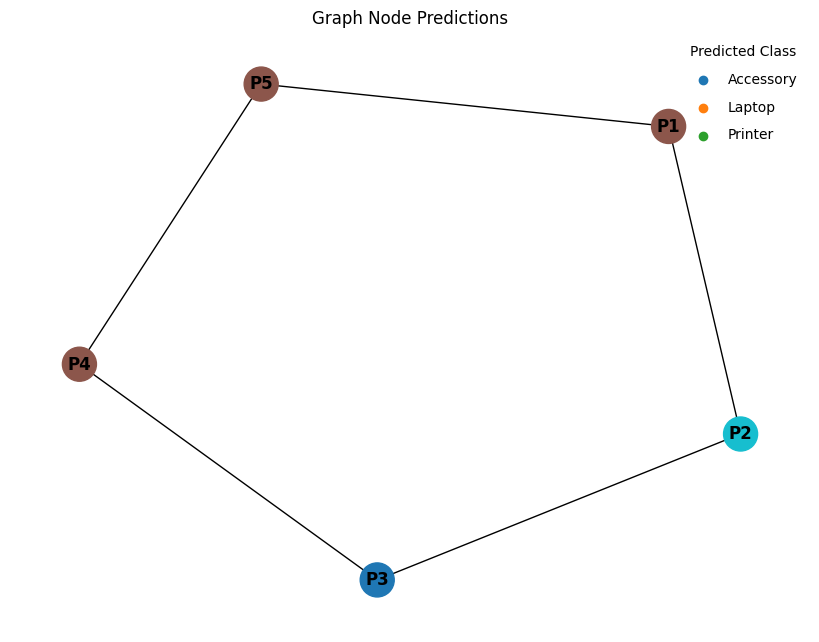

In [57]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Use your predicted DataFrame
# df_all = predict_nodes(model, data)

# Build graph
G = nx.Graph()
edges = pd.read_csv("data/raw/edges.csv")  # Your edges CSV

# Add nodes
for nid in data.node_ids:
    G.add_node(nid)

# Add edges
for _, row in edges.iterrows():
    G.add_edge(row['source'], row['target'])

# Create a color map based on predicted class
class_colors = {cls: i for i, cls in enumerate(data.class_names)}
node_colors = [class_colors[df_all.loc[df_all.node_id==nid, "predicted_class"].values[0]] for nid in G.nodes]

# Draw the graph
plt.figure(figsize=(8,6))
nx.draw(
    G, 
    with_labels=True, 
    node_color=node_colors, 
    cmap=plt.cm.tab10,  # Use a qualitative colormap
    node_size=600,
    font_weight='bold'
)
# Add legend
for cls, idx in class_colors.items():
    plt.scatter([], [], c=[plt.cm.tab10(idx)], label=cls)
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title="Predicted Class")
plt.title("Graph Node Predictions")
plt.show()


In [66]:
def predict_for_selected_nodes(model, data, target_node_ids):
    """
    Predict only for a subset of nodes.

    Parameters
    ----------
    model : torch.nn.Module
        The trained model.
    data : Data
        PyTorch Geometric Data object.
    target_node_ids : list or tensor
        Node indices to filter predictions for.

    Returns
    -------
    torch.Tensor
        Predictions only for the selected nodes.
    """
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        # Filter predictions for only the desired node_ids
        mask = torch.zeros(out.size(0), dtype=torch.bool)
        mask[target_node_ids] = True
        return out[mask]
